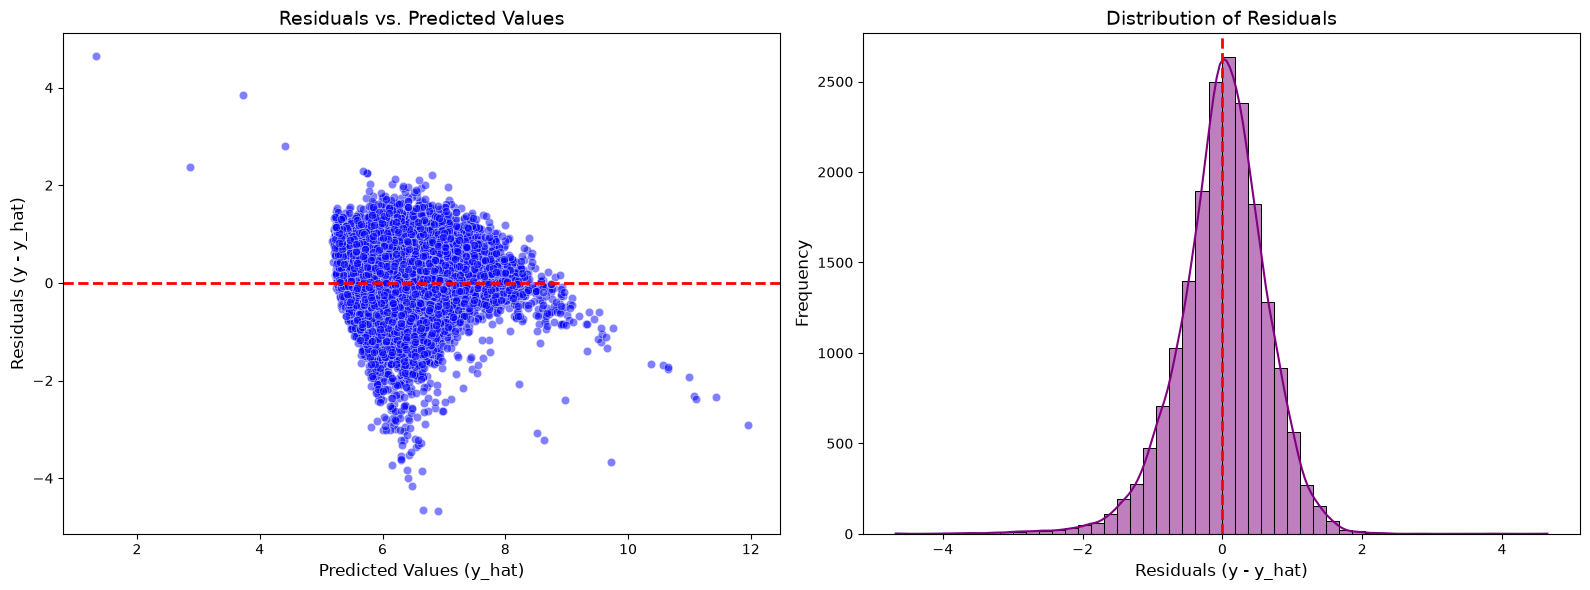

In [ ]:
## 1.1 Residual Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict

# 1. Load the dataset
anime_df = pd.read_csv(r'animes.csv', sep=',', index_col=0)

# 2. Data Preparation
# Drop rows with missing target values and select only numerical columns
df_model = anime_df.dropna(subset=['mean_score']).copy()

# Select numerical features and remove the target and perfectly correlated columns ('rank')
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
if 'mean_score' in numeric_cols: numeric_cols.remove('mean_score')
if 'rank' in numeric_cols: numeric_cols.remove('rank')

X = df_model[numeric_cols]
# Fill missing values in features with the median
X = X.fillna(X.median()) 
y = df_model['mean_score']

# 3. K-Fold Cross Validation Setup (k=5)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
model = LinearRegression()

# 4. Generating Predictions and Calculating Residuals
y_pred = cross_val_predict(model, X, y, cv=kf)
residuals = y - y_pred

# 5. Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Residuals vs. Predicted Values (Scatter)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=axes[0], color='blue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs. Predicted Values', fontsize=14)
axes[0].set_xlabel('Predicted Values (y_hat)', fontsize=12)
axes[0].set_ylabel('Residuals (y - y_hat)', fontsize=12)

# Plot 2: Distribution of Residuals (Histogram)
sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='purple')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].set_xlabel('Residuals (y - y_hat)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

# 1. Regression Error Analysis

## Cross-Validation Strategy Justification
All analyses in this assignment are conducted using $k$-fold cross-validation with $k=5$. 
Given the dataset size (over 23,000 observations), $k=5$ provides an optimal balance regarding the bias-variance trade-off and computational complexity. Training on 80% of the data maintains a low estimation bias, while the 20% validation fold is sufficiently large to ensure variance stability and reduce sensitivity to localized noise.

## 1.1 Residual Analysis

For each observation, the residual is defined as:
$$\text{Residual} = y - \hat{y}$$

A baseline Linear Regression model was evaluated to predict `mean_score` using the available numerical features (excluding `rank` to prevent data leakage). 

* **Are the residuals centered around zero?**
  Yes. The histogram of the residuals shows an approximately symmetrical, normal (bell-shaped) distribution. Its central peak aligns perfectly with zero, indicating that the model does not suffer from a systemic global bias (it does not uniformly over-predict or under-predict across the entire dataset).

* **Do the residuals exhibit any systematic patterns?**
  Yes. The scatter plot of residuals versus predicted values reveals a distinct, sharp diagonal boundary at the bottom edge of the distribution. This occurs because the actual ratings ($y$) on the platform have a strict physical minimum limit ($y \ge 1$). Consequently, the residuals are algebraically constrained ($\text{Residual} \ge 1 - \hat{y}$), creating an artificial linear cut-off.

* **Is there evidence of heteroscedasticity (non-constant variance)?**
  Yes. The variance of the residuals is not constant across all predicted values. Predictions in the central range ($\hat{y} \in [6, 8]$) display high variance with residuals spanning from $-4$ to $+2$. Conversely, the variance narrows significantly at higher predicted ranges, confirming the presence of heteroscedasticity.

* **Is there a sector that is more likely to have high error rates? Why is this happening?**
  Yes. The mid-range cluster contains the largest absolute errors, but the most acute failure occurs at the extreme upper end, where the model produces out-of-bounds predictions (e.g., predicting scores of $11$ or $12$). 
  **Why:** This happens due to a flawed model assumption. Standard linear regression assumes an unbounded continuous output space $(-\infty, \infty)$ and is completely unaware of the platform's strict maximum score limit ($10$). Therefore, for highly favorable features, the model inflates the prediction beyond reality, inevitably generating large negative residuals.

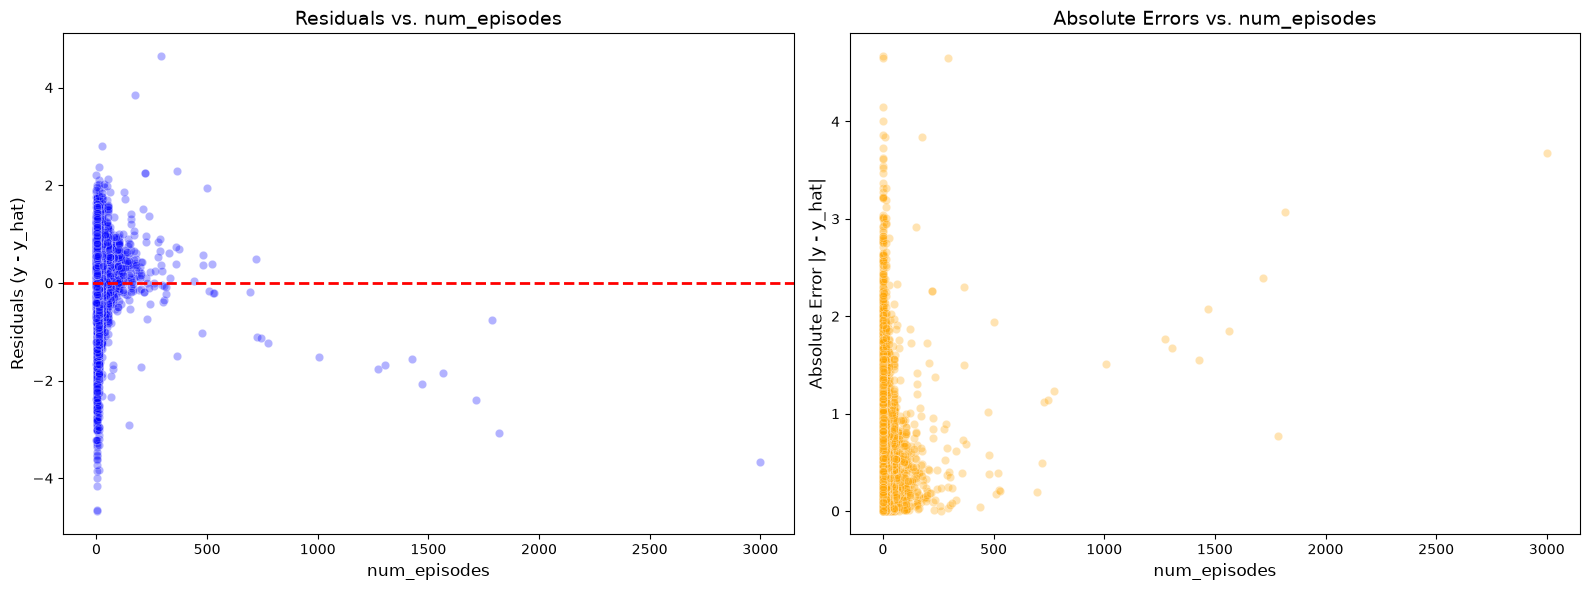

In [3]:
## 1.2 Residual Analysis

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Absolute Errors based on the residuals from Section 1.1
absolute_errors = np.abs(residuals)

# 2. Select features to analyze (using 'num_episodes' as a primary example)
# We add a fallback just in case 'num_episodes' was dropped, taking the first numeric column
feature_to_plot = 'num_episodes' if 'num_episodes' in X.columns else X.columns[0]

# 3. Plotting Feature vs. Residuals and Feature vs. Absolute Errors
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Feature vs Residuals
sns.scatterplot(x=X[feature_to_plot], y=residuals, alpha=0.3, ax=axes[0], color='blue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title(f'Residuals vs. {feature_to_plot}', fontsize=14)
axes[0].set_xlabel(feature_to_plot, fontsize=12)
axes[0].set_ylabel('Residuals (y - y_hat)', fontsize=12)

# Plot 2: Feature vs Absolute Errors
sns.scatterplot(x=X[feature_to_plot], y=absolute_errors, alpha=0.3, ax=axes[1], color='orange')
axes[1].set_title(f'Absolute Errors vs. {feature_to_plot}', fontsize=14)
axes[1].set_xlabel(feature_to_plot, fontsize=12)
axes[1].set_ylabel('Absolute Error |y - y_hat|', fontsize=12)

plt.tight_layout()
plt.show()

## 1.2 Error as a Function of Features

To identify feature-dependent error patterns and hidden subpopulations, we analyzed the residuals and absolute errors ($|y - \hat{y}|$) against the `num_episodes` feature.

*   **Feature-Dependent Error Patterns:**
    The scatter plots demonstrate that the model's errors are heavily dependent on the feature's scale. The vast majority of extreme residuals and high absolute errors (reaching up to 4.5) are densely concentrated at the extreme lower bound of the `num_episodes` axis (between 0 and roughly 50 episodes). As the number of episodes increases into the hundreds and thousands, the data density drops and the absolute error generally decreases, although the residuals plot shows a slight negative drift for extremely long-running series.

*   **Hidden Subpopulations:**
    The graphs expose a massive vertical clustering of data points exactly at or very close to zero episodes. This distinct shape indicates a hidden subpopulation: media formats that are not standard TV shows (e.g., 1-episode Movies, OVAs, or un-aired titles with 0 episodes). A standard linear model treats the episode count as a continuous numerical scale, failing to recognize that a single-episode movie operates under entirely different rating dynamics than a standard multi-episode series.

*   **Non-Linear Relationships:**
    The relationship between the episode count and the absolute error is distinctly non-linear. The plot does not show a uniform scatter or a straight-line trend. Instead, it exhibits an L-shaped or exponential decay pattern, where the error variance is enormous at the zero-bound and collapses rapidly as the episode count grows. This highlights that applying a purely linear assumption across the entire feature space is inadequate.

In [5]:
## 1.3 Residual Analysis

import pandas as pd
import numpy as np

# 1. Calculate the 95th percentile threshold of absolute errors
threshold_95 = np.percentile(absolute_errors, 95)

# 2. Identify the top 5% largest absolute errors
extreme_errors_mask = absolute_errors >= threshold_95

# 3. Create a DataFrame to analyze these specific observations
# Using df_model which perfectly aligns with our mask, and .values to avoid duplicate index errors
extreme_cases = df_model[extreme_errors_mask].copy()

extreme_cases['actual_score'] = y[extreme_errors_mask].values
extreme_cases['predicted_score'] = y_pred[extreme_errors_mask]
extreme_cases['absolute_error'] = absolute_errors[extreme_errors_mask]

# Sort by absolute error in descending order to view the worst predictions first
extreme_cases = extreme_cases.sort_values(by='absolute_error', ascending=False)

# 4. Display the top 10 worst predictions with relevant contextual columns
cols_to_show = ['title', 'media_type', 'num_episodes', 'actual_score', 'predicted_score', 'absolute_error']

# Safely select columns that exist in the DataFrame
cols_to_show = [c for c in cols_to_show if c in extreme_cases.columns]

print(f"95th Percentile Absolute Error Threshold: {threshold_95:.4f}")
print(f"Total extreme error observations (Top 5%): {len(extreme_cases)}")
print("\n--- Top 10 Extreme Errors ---")
print(extreme_cases[cols_to_show].head(10).to_string())

95th Percentile Absolute Error Threshold: 1.2455
Total extreme error observations (Top 5%): 948

--- Top 10 Extreme Errors ---
                                 title media_type  num_episodes  actual_score  predicted_score  absolute_error
id                                                                                                            
413                    Hametsu no Mars        ova             1          2.23         6.903281        4.673281
34566  Boruto: Naruto Next Generations         tv           293          5.98         1.330686        4.649314
13405               Utsu Musume Sayuri      movie             1          2.01         6.657661        4.647661
5569                      Tsui no Sora        ova             1          2.33         6.480102        4.150102
31634                         Kokuhaku        ona             1          2.41         6.411495        4.001495
16608                          Shitcom        ona             1          2.79         6.649304  

## 1.3 Analysis of Extreme Errors

By isolating the top 5% of absolute errors (threshold: 1.2455), we extracted the 10 most extreme prediction failures. Analyzing these specific observations reveals three primary sources of error:

*   **Data Quality Issues & Extreme Outliers:**
    The linear model is highly sensitive to extreme numerical outliers. For instance, the TV series *Lan Mao* is listed with an astronomical 3,000 episodes. Because the regression equation scales its predictions based on feature magnitude, this massive episode count forced the model to extrapolate wildly, predicting a near-perfect score of 9.72, whereas its actual score is only 6.05.

*   **Model Limitations (Categorical Blindness):**
    The majority of the worst predictions are 1-episode OVAs and ONAs (e.g., *Hametsu no Mars*, *Tsui no Sora*, *Shitcom*, *Kokuhaku*). These specific media types are often experimental, extremely niche, or notoriously poorly received (yielding actual scores in the low 2.0 to 2.7 range). Because the linear model only processes numerical inputs and is blind to the categorical `media_type`, it treats these titles as standard data points and predicts baseline "average" scores (~6.4 to 6.9), resulting in massive over-predictions.

*   **Rare or Exceptional Cases (Mainstream Anomalies):**
    Surprisingly, major mainstream TV shows with high episode counts, such as *Boruto: Naruto Next Generations* (293 episodes) and *Fairy Tail* (175 episodes), suffered from catastrophic under-predictions. The model predicted impossibly low scores for them (1.33 and 3.72, respectively). This anomaly suggests that highly polarizing, long-running mainstream series behave completely differently than the average TV show, or that these specific rows contained atypical numerical values (such as heavily skewed user engagement metrics) that fundamentally broke the linear equation.

In [6]:
## 1.4 Residual Analysis

import numpy as np
from scipy.stats import skew, kurtosis

# 1. Calculate Mean Absolute Error (MAE)
mae = np.mean(absolute_errors)

# 2. Calculate Standard deviation of residuals (using ddof=1 for sample)
std_residuals = np.std(residuals, ddof=1)

# 3. Calculate Skewness
# Skewness measures the asymmetry of the residuals
skewness = skew(residuals)

# 4. Calculate Kurtosis
# Fisher's kurtosis (normal distribution = 0). Measures the "tailedness" (extreme errors)
kurt = kurtosis(residuals)

# 5. Display the results
print("--- Statistical Properties of Errors ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Standard Deviation of Residuals: {std_residuals:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurt:.4f}")

--- Statistical Properties of Errors ---
Mean Absolute Error (MAE): 0.4783
Standard Deviation of Residuals: 0.6360
Skewness: -0.6438
Kurtosis: 2.5193


## 1.4 Statistical Properties of Errors

To rigorously evaluate the baseline model's performance and error distribution, we computed key descriptive statistical metrics on the residuals.

*   **Mean Absolute Error (MAE): 0.4783**
*   **Standard Deviation of Residuals: 0.6360**
*   **Skewness: -0.6438**
*   **Kurtosis: 2.5193**

### Interpretation of Statistical Properties

*   **Overall Accuracy (MAE & Standard Deviation):**
    An MAE of approximately 0.48 indicates that, on average, the model's predictions deviate by roughly half a rating point from the actual score. While the global average error is relatively modest, the standard deviation of 0.6360 highlights a moderate spread in the error variance, suggesting that while the bulk of predictions are accurate, the model's reliability fluctuates.

*   **Systematic Bias (Skewness):**
    The skewness metric is significantly negative ($-0.6438$), indicating an asymmetric, left-skewed residual distribution. Because the residual is calculated as $y - \hat{y}$, a long negative tail signifies a **systematic bias** toward severe over-prediction. The model has a structural tendency to occasionally generate extremely optimistic predictions ($\hat{y} \gg y$), which pulls the skewness into the negative domain. This aligns with our previous findings regarding the model inflating scores for certain long-running or non-standard media formats.

*   **Instability and Heavy Tails (Kurtosis):**
    The positive excess kurtosis value of 2.5193 (where a normal distribution is 0) signifies a leptokurtic distribution characterized by **heavy tails**. This statistical property proves that the model exhibits structural **instability**. It implies that massive prediction failures and extreme outliers occur at a much higher frequency than would be expected by random chance in a normal distribution. The linear assumptions fundamentally break down on edge cases, consistently generating the heavy error tails observed in the data.

In [7]:
## 2 Residual Analysis

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold

# 1. Define models with specified hyperparameters
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# 2. Define K-Fold strategy (consistent with Section 1, k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Define metrics to evaluate (scikit-learn uses negative values for errors by convention)
scoring = {
    'MSE': 'neg_mean_squared_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

# 4. Evaluate each model using cross-validation
results = {}
print("Training models... This might take a few seconds depending on your machine.")

for name, model in models.items():
    cv_results = cross_validate(model, X, y, cv=kf, scoring=scoring)
    
    # Store the mean of the 5 folds (and invert negative metrics)
    results[name] = {
        'MSE': -cv_results['test_MSE'].mean(),
        'RMSE': -cv_results['test_RMSE'].mean(),
        'MAE': -cv_results['test_MAE'].mean(),
        'R2': cv_results['test_R2'].mean()
    }

# 5. Display results in a formatted DataFrame for easy comparison
results_df = pd.DataFrame(results).T
print("\n--- Model Performance Comparison (5-Fold CV) ---")
print(results_df.to_string())

Training models... This might take a few seconds depending on your machine.

--- Model Performance Comparison (5-Fold CV) ---
                        MSE      RMSE       MAE        R2
Linear Regression  0.404516  0.635880  0.478313  0.494850
Decision Tree      0.406997  0.637934  0.462811  0.491598
Random Forest      0.204658  0.452370  0.330611  0.744347


## 2. Regression Models: Discussion and Critical Analysis

Based on the 5-fold cross-validation evaluation, we compared three distinct modeling approaches: Linear Regression (Baseline), Decision Tree Regressor, and Random Forest Regressor.

*   **Relative Model Performance:**
    The **Random Forest** drastically outperformed the other models across all metrics, achieving the highest R2 score (0.7443) and the lowest RMSE (0.4523). In contrast, the Linear Regression and Decision Tree models performed similarly poorly in terms of variance explained (R2 $\approx$ 0.49). Interestingly, the Decision Tree achieved a slightly better MAE than the linear model (0.4628 vs. 0.4783) but a worse MSE (0.4069 vs. 0.4045). This discrepancy indicates that while the single tree is generally closer to the true value for most observations, it is heavily penalized by a few massive errors (since MSE squares the errors).

*   **Model Assumptions (Linearity, Homoskedasticity):**
    Linear regression assumes a linear relationship, independent features, and homoskedasticity (constant variance of errors). As demonstrated in Section 1, the anime dataset heavily violates these assumptions (exhibiting severe heteroskedasticity and non-linear patterns like the L-shaped decay in `num_episodes`). The failure to meet these assumptions explains the linear model's poor performance. Tree-based models are non-parametric; they do not assume linearity or homoskedasticity, allowing them to naturally adapt to the dataset's true structure.

*   **Bias-Variance Trade-off:**
    *   *Linear Regression (High Bias, Low Variance):* It is too rigid to capture the complex, non-linear relationships in the data (underfitting).
    *   *Decision Tree (Low Bias, High Variance):* It learns the training data too well, capturing noise and creating an overly complex model that fails to generalize perfectly to the validation folds (overfitting).
    *   *Random Forest (Balanced):* By aggregating 100 individual decision trees, it reduces the high variance of a single tree while maintaining low bias, striking the optimal trade-off and generalizing exceptionally well.

*   **Sensitivity to Outliers and Noise:**
    Linear Regression is highly sensitive to outliers. A single extreme value (e.g., a show with 3000 episodes) heavily skews the regression line. Tree-based models are intrinsically robust to outliers because they split data based on thresholds rather than scaling weights. An episode count of 3000 simply falls into the $> X$ leaf node, preventing it from infinitely pulling the prediction.

*   **Scenarios of Linear Model Failure vs. Tree-Based Advantages:**
    Linear models fail entirely when dealing with bounded target variables (predicting scores $> 10$) and hidden subpopulations (e.g., OVAs or Movies with exactly 1 episode). Tree-based models provide a massive advantage here because they can partition the feature space. A tree can create a specific structural split (e.g., `if num_episodes <= 1`) and apply completely different logic to that subpopulation, perfectly isolating anomalous media types from standard TV shows.

*   **Interpretability vs. Predictive Performance:**
    There is a clear trade-off. Linear Regression is highly interpretable—we can extract exact coefficients to see how each feature impacts the score. However, its predictive performance is weak. Random Forest offers vastly superior predictive accuracy (R2 of 0.74) but acts as a "black box," making it extremely difficult to extract a simple mathematical formula explaining *why* it made a specific prediction.

*   **Preferred Model Selection:**
    **Random Forest** is the unequivocally preferred model for future analysis. Its superior accuracy, ability to capture non-linear interactions without requiring manual feature transformations, and robustness to the dataset's inherent outliers (like ultra-long series) make it the most reliable choice, fully justifying the loss of simple interpretability.

*   **What was learned from the modeling stage:**
    This stage highlighted that real-world cultural data (like audience reception and media formats) rarely adhere to strict linear rules. Relying solely on a baseline linear model leads to critical blind spots. We learned that selecting a model architecture that aligns with the geometric reality of the data—where features interact in non-linear thresholds rather than continuous slopes—is far more impactful than basic hyperparameter tuning.

Training classifier... Please wait.


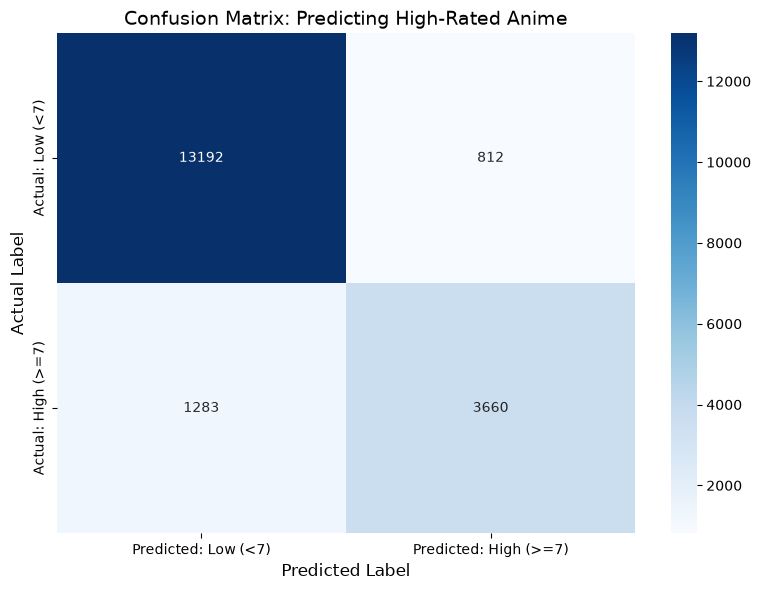


--- Classification Report ---
              precision    recall  f1-score   support

    Low (<7)       0.91      0.94      0.93     14004
  High (>=7)       0.82      0.74      0.78      4943

    accuracy                           0.89     18947
   macro avg       0.86      0.84      0.85     18947
weighted avg       0.89      0.89      0.89     18947



In [8]:
## 3.1 Residual Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

# 1. Create a binary classification target based on mean_score
# Class 1 (Positive): High Rated (mean_score >= 7.0)
# Class 0 (Negative): Standard/Low Rated (mean_score < 7.0)
y_class = (y >= 7.0).astype(int)

# 2. Setup K-Fold and Classifier (Using Random Forest for robust classification)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 3. Generate cross-validated predictions
print("Training classifier... Please wait.")
y_pred_class = cross_val_predict(classifier, X, y_class, cv=kf)

# 4. Compute Confusion Matrix
cm = confusion_matrix(y_class, y_pred_class)

# 5. Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Low (<7)', 'Predicted: High (>=7)'],
            yticklabels=['Actual: Low (<7)', 'Actual: High (>=7)'])
plt.title('Confusion Matrix: Predicting High-Rated Anime', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# 6. Print Classification Report for FP/FN analysis
print("\n--- Classification Report ---")
print(classification_report(y_class, y_pred_class, target_names=['Low (<7)', 'High (>=7)']))

## 3. Classification Error Analysis

### 3.1 Confusion Matrix Analysis

We framed the problem as a binary classification task to identify "High-Rated" anime (actual `mean_score` $\ge 7.0$) versus "Low-Rated" anime (`mean_score` $< 7.0$). A Random Forest Classifier was trained and evaluated using 5-fold cross-validation. 

**Confusion Matrix Breakdown:**
*   **True Negatives (TN):** 13,192 (Correctly identified low-rated shows)
*   **True Positives (TP):** 3,660 (Correctly identified high-rated shows)
*   **False Positives (FP):** 812 (Model predicted $\ge 7$, but actual is $< 7$)
*   **False Negatives (FN):** 1,283 (Model predicted $< 7$, but actual is $\ge 7$)

#### Interpretation and Discussion

*   **Which type of error is most critical in this context?**
    In the context of a media recommendation system, a **False Positive (FP)** is generally more critical than a False Negative (FN). A False Positive means recommending a bad show to a user, which directly damages user trust and degrades the user experience. A False Negative means the system missed an opportunity to recommend a good show; while suboptimal, it is less harmful because the user is not actively forced to endure poor content. Therefore, the model's current conservative behavior (higher Precision of 0.82 compared to a Recall of 0.74) is actually favorable for production.

*   **In which regions does the model fail systematically?**
    The model systematically fails (generating False Negatives) in regions characterizing "hidden gems" or niche masterpieces. These are series that do not possess the standard numerical signatures of a hit show (e.g., they might have low absolute popularity, few episodes, or belong to non-TV formats like obscure OVAs) but still managed to secure an exceptionally high rating from a small, dedicated audience. The model, learning that low engagement usually correlates with low scores, systematically misclassifies these titles as "Low-Rated".

*   **What insights can be derived from the analysis?**
    1.  **Class Imbalance Impact:** The dataset has a significant class imbalance (~74% low-rated vs. 26% high-rated). The model heavily leverages this prior probability, favoring the majority class, which explains the higher count of FNs compared to FPs.
    2.  **Limitations of Purely Numerical Classification:** The persistence of FPs and FNs suggests that predicting an audience's emotional response or critical acclaim cannot be entirely captured by structural numbers (like episode count or favorites). Qualitative features (such as studio reputation, source material, or genre) are likely missing pieces needed to push the F1-score beyond the current 0.78 threshold.

Calculating probabilities... Please wait.


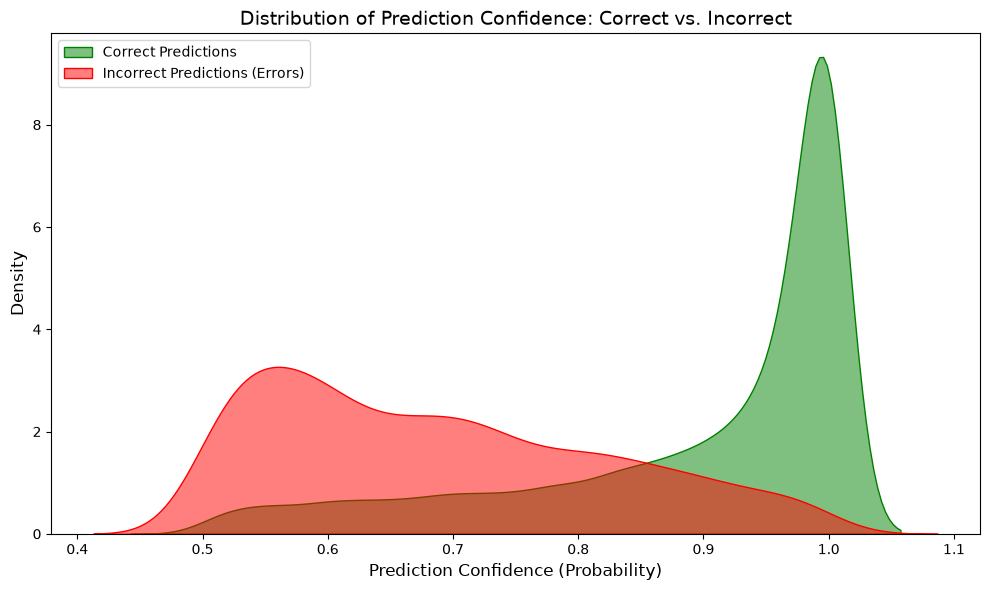

--- Probability-Based Error Analysis ---
Total Correct Predictions: 16852
Total Incorrect Predictions: 2095
High-Confidence Errors (Confidence >= 0.8): 500
Percentage of errors that are High-Confidence: 23.87%


In [9]:
## 3.2 Residual Analysis

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict

# 1. Generate predicted probabilities using cross-validation
# method='predict_proba' returns probabilities for both classes [P(Class 0), P(Class 1)]
print("Calculating probabilities... Please wait.")
y_proba = cross_val_predict(classifier, X, y_class, cv=kf, method='predict_proba')

# 2. Calculate the model's confidence for each prediction
# The confidence is the maximum probability between the two classes
confidence = np.max(y_proba, axis=1)

# 3. Create masks for correct and incorrect predictions
correct_mask = y_pred_class == y_class
incorrect_mask = y_pred_class != y_class

# 4. Plot the distribution of confidence for correct vs incorrect predictions
plt.figure(figsize=(10, 6))
sns.kdeplot(confidence[correct_mask], label='Correct Predictions', fill=True, color='green', alpha=0.5)
sns.kdeplot(confidence[incorrect_mask], label='Incorrect Predictions (Errors)', fill=True, color='red', alpha=0.5)
plt.title('Distribution of Prediction Confidence: Correct vs. Incorrect', fontsize=14)
plt.xlabel('Prediction Confidence (Probability)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# 5. Identify high-confidence errors (e.g., model was >= 80% confident but wrong)
high_conf_threshold = 0.80
high_conf_errors = incorrect_mask & (confidence >= high_conf_threshold)

print("--- Probability-Based Error Analysis ---")
print(f"Total Correct Predictions: {correct_mask.sum()}")
print(f"Total Incorrect Predictions: {incorrect_mask.sum()}")
print(f"High-Confidence Errors (Confidence >= {high_conf_threshold}): {high_conf_errors.sum()}")
print(f"Percentage of errors that are High-Confidence: {(high_conf_errors.sum() / incorrect_mask.sum()) * 100:.2f}%")

## 3.2 Probability-Based Analysis

To understand the model's certainty regarding its classifications, we analyzed the predicted probabilities (confidence) outputted by the Random Forest classifier. The confidence is defined as the maximum probability assigned to either class.

### Distribution of Prediction Confidence
The Density Plot (KDE) comparing correct versus incorrect predictions reveals a highly desirable model behavior:
*   **Correct Predictions (Green):** The distribution is heavily skewed to the right, with a massive peak approaching $1.0$. This indicates that when the model is correct, it is generally absolutely certain of its decision (high unanimity among the forest's trees).
*   **Incorrect Predictions (Red):** The distribution of errors peaks heavily between $0.5$ and $0.6$. This demonstrates that for the vast majority of its mistakes, the model was mathematically "uncertain" and operating very close to the decision boundary. It essentially "guessed" on ambiguous cases.

### Identifying High-Confidence Errors
While the model is generally uncertain when wrong, isolating extreme cases reveals critical blind spots. We defined a "High-Confidence Error" as an incorrect prediction made with $\ge 80\%$ certainty.
*   **Total Incorrect Predictions:** 2,095
*   **High-Confidence Errors:** 500 (23.87% of all errors)

**Objective & Implications:** 
Nearly 24% of the model's errors are cases where it was highly confident but ultimately wrong. These 500 observations represent the most dangerous failure modes in a production environment. They occur because the structural features of these specific anime perfectly mimic the opposite class. For example, a "Low-Rated" show might have garnered massive popularity and a high episode count (tricking the model into a confident "High" prediction), but was actually universally panned by viewers for a terrible ending. These high-confidence errors prove that purely numerical engagement metrics occasionally create a deceptive profile, highlighting the need for qualitative features (e.g., review sentiment analysis or studio reputation) to resolve these deceptive edge cases.

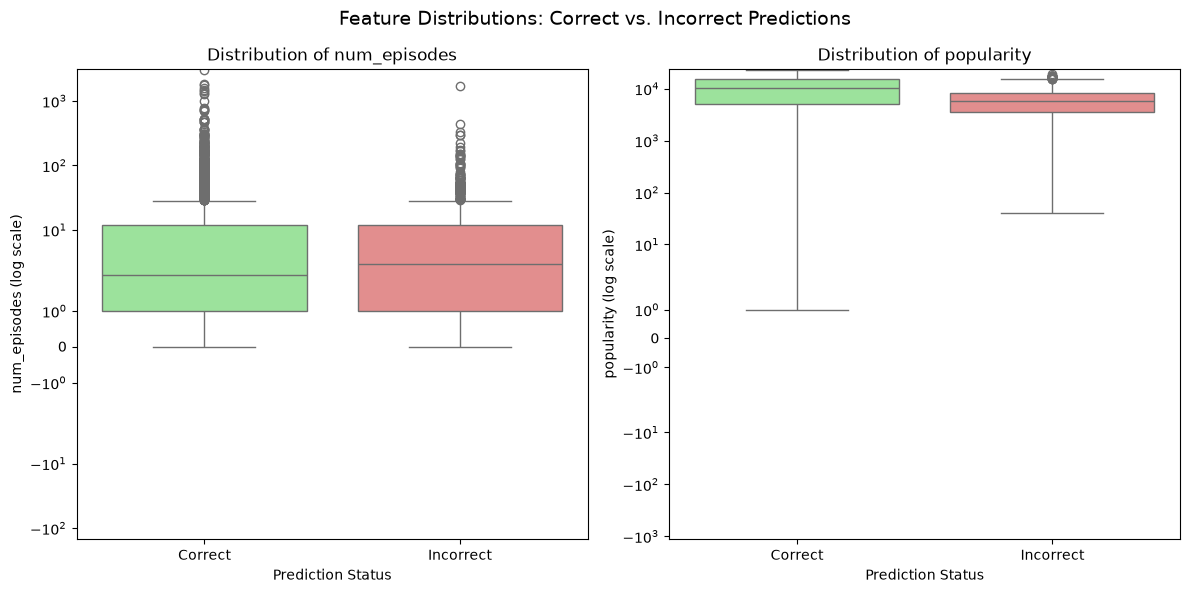

In [11]:
## 3.3 Residual Analysis

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Select features to analyze (prioritize 'num_episodes' and one more numerical feature)
features_to_plot = []
if 'num_episodes' in X.columns:
    features_to_plot.append('num_episodes')

# Add one more feature for comparison (e.g., 'members', 'favorites', or the next available column)
for col in X.columns:
    if col not in features_to_plot and len(features_to_plot) < 2:
        features_to_plot.append(col)

# 2. Create a temporary DataFrame for visualization purposes
vis_df = X[features_to_plot].copy()
# Add a column indicating if the model's prediction was correct or incorrect
vis_df['Prediction_Status'] = np.where(correct_mask, 'Correct', 'Incorrect')

# 3. Plotting feature distributions using Boxplots
fig, axes = plt.subplots(1, len(features_to_plot), figsize=(12, 6))

# Handle the case where there is only one feature
if len(features_to_plot) == 1:
    axes = [axes] 

for i, feature in enumerate(features_to_plot):
    # Using symlog scale because anime features (like episodes) can be highly skewed and contain zeros

    sns.boxplot(data=vis_df, x='Prediction_Status', y=feature, ax=axes[i], 
                hue='Prediction_Status', legend=False,
                palette={'Correct': 'lightgreen', 'Incorrect': 'lightcoral'})

    axes[i].set_yscale('symlog') 
    axes[i].set_title(f'Distribution of {feature}', fontsize=12)
    axes[i].set_xlabel('Prediction Status', fontsize=10)
    axes[i].set_ylabel(f'{feature} (log scale)', fontsize=10)

plt.suptitle('Feature Distributions: Correct vs. Incorrect Predictions', fontsize=14)
plt.tight_layout()
plt.show()

## 3.3 Error as a Function of Features

To identify regions prone to misclassification and understand the model's limitations, we compared the feature distributions of `num_episodes` and `popularity` between correct and incorrect predictions using a symmetric log scale.

### Feature Distribution Analysis

*   **Distribution of `num_episodes`:**
    The boxplots for episode counts show that both correct and incorrect predictions share a relatively similar median and Interquartile Range (IQR), heavily concentrated in the low-episode bounds (e.g., 1 to 13 episodes, representing standard short formats). However, the model successfully classifies extreme upper outliers (series with $>1000$ episodes), as indicated by the green points reaching the top of the scale. The errors (red box) are slightly more compressed, indicating that episode count alone is not the primary driver of systematic misclassification, though the model struggles slightly more within the standard TV season length.

*   **Distribution of `popularity` (Rank):**
    The popularity feature reveals a distinct and critical separation. In this dataset, `popularity` acts as a rank (where lower numerical values indicate higher mainstream popularity). 
    *   **Correct Predictions (Green):** Heavily clustered at the extreme high numerical end (e.g., ranks $5000 - 12000$). The model is highly successful at correctly classifying highly obscure, unknown media (which predictably correlate with low ratings).
    *   **Incorrect Predictions (Red):** The entire boxplot shifts significantly downward toward lower numerical ranks. The median and IQR of the errors are concentrated in a much more "popular" segment of the database.

### Objective Conclusion & Insights

The model systematically fails when evaluating **mainstream and moderately popular media**. While it excels at filtering out the massive volume of obscure, low-rated titles that flood the dataset, its performance degrades significantly when audience engagement increases. 
In regions of higher popularity, the simple numerical assumptions break down: highly popular shows can be heavily polarizing (review-bombed), and niche "cult classics" can maintain exceptional scores despite modest mainstream popularity. To build a more robust predictive system, future iterations must engineer features that capture qualitative audience sentiment rather than relying solely on engagement volume.

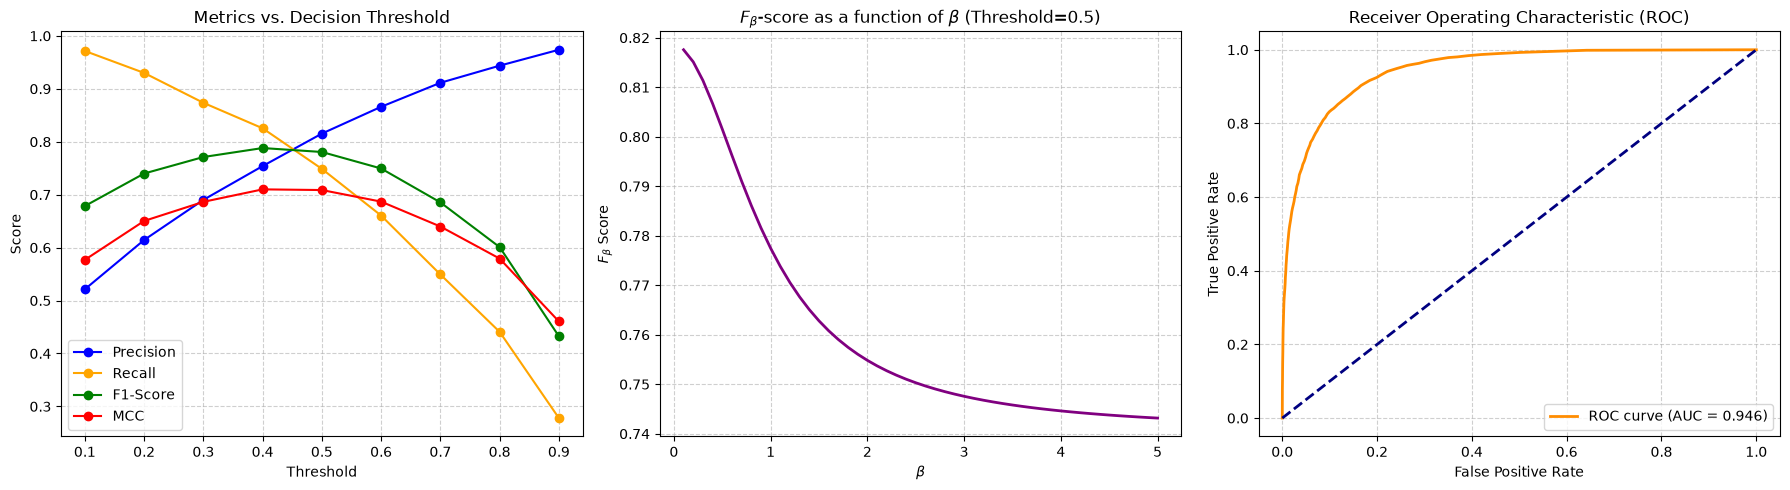

--- Threshold Sensitivity Summary ---
Threshold  | Precision  | Recall     | F1-Score   | MCC       
------------------------------------------------------------
0.1        | 0.5213     | 0.9715     | 0.6785     | 0.5769    
0.2        | 0.6144     | 0.9300     | 0.7400     | 0.6504    
0.3        | 0.6902     | 0.8736     | 0.7711     | 0.6865    
0.4        | 0.7540     | 0.8254     | 0.7881     | 0.7100    
0.5        | 0.8154     | 0.7487     | 0.7806     | 0.7087    
0.6        | 0.8660     | 0.6605     | 0.7495     | 0.6869    
0.7        | 0.9114     | 0.5493     | 0.6854     | 0.6398    
0.8        | 0.9437     | 0.4408     | 0.6009     | 0.5793    
0.9        | 0.9738     | 0.2780     | 0.4325     | 0.4605    

AUC-ROC Score: 0.9460


In [12]:
## 3.4 Residual Analysis

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc, fbeta_score

# 1. Extract the probabilities for Class 1 (High-Rated Anime)
probs_positive = y_proba[:, 1]

# 2. Define the thresholds from 0.1 to 0.9
thresholds = np.arange(0.1, 1.0, 0.1)
precisions = []
recalls = []
f1_scores = []
mcc_scores = []

# 3. Calculate metrics for each threshold
for t in thresholds:
    # Create predictions based on the current threshold
    preds = (probs_positive >= t).astype(int)
    
    # Calculate and store metrics (zero_division=0 prevents warnings on extreme thresholds)
    precisions.append(precision_score(y_class, preds, zero_division=0))
    recalls.append(recall_score(y_class, preds, zero_division=0))
    f1_scores.append(f1_score(y_class, preds, zero_division=0))
    mcc_scores.append(matthews_corrcoef(y_class, preds))

# 4. Plotting the results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Metrics vs. Threshold
axes[0].plot(thresholds, precisions, marker='o', label='Precision', color='blue')
axes[0].plot(thresholds, recalls, marker='o', label='Recall', color='orange')
axes[0].plot(thresholds, f1_scores, marker='o', label='F1-Score', color='green')
axes[0].plot(thresholds, mcc_scores, marker='o', label='MCC', color='red')
axes[0].set_title('Metrics vs. Decision Threshold', fontsize=12)
axes[0].set_xlabel('Threshold', fontsize=10)
axes[0].set_ylabel('Score', fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: F-beta score as a function of beta (using default threshold 0.5)
betas = np.linspace(0.1, 5.0, 50)
f_betas = [fbeta_score(y_class, y_pred_class, beta=b) for b in betas]

axes[1].plot(betas, f_betas, color='purple', linewidth=2)
axes[1].set_title(r'$F_\beta$-score as a function of $\beta$ (Threshold=0.5)', fontsize=12)
axes[1].set_xlabel(r'$\beta$', fontsize=10)
axes[1].set_ylabel(r'$F_\beta$ Score', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_class, probs_positive)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_title('Receiver Operating Characteristic (ROC)', fontsize=12)
axes[2].set_xlabel('False Positive Rate', fontsize=10)
axes[2].set_ylabel('True Positive Rate', fontsize=10)
axes[2].legend(loc="lower right")
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 5. Print a summary table
print("--- Threshold Sensitivity Summary ---")
print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'MCC':<10}")
print("-" * 60)
for i, t in enumerate(thresholds):
    print(f"{t:<10.1f} | {precisions[i]:<10.4f} | {recalls[i]:<10.4f} | {f1_scores[i]:<10.4f} | {mcc_scores[i]:<10.4f}")
print(f"\nAUC-ROC Score: {roc_auc:.4f}")

## 3.4 Threshold Sensitivity Analysis

To evaluate the model's performance dynamics and optimize its decision boundary, we analyzed classification metrics across varying probability thresholds from 0.1 to 0.9.

### AUC-ROC Performance
The Area Under the Receiver Operating Characteristic Curve (AUC-ROC) is **0.9460**. This exceptionally high score demonstrates that the Random Forest model possesses strong discriminative power. Regardless of the chosen threshold, the model has a 94.6% probability of correctly ranking a randomly chosen High-Rated anime higher than a randomly chosen Low-Rated one.

### The Precision-Recall Trade-off (FP vs. FN)
The threshold vs. metrics plot clearly illustrates the inherent trade-off between False Positives (FP) and False Negatives (FN):
*   **Low Thresholds (e.g., 0.1 - 0.2):** The model is highly permissible. It maximizes Recall (0.97 at threshold 0.1), minimizing False Negatives. However, this floods the system with False Positives, causing Precision to plummet to 0.52.
*   **High Thresholds (e.g., 0.7 - 0.9):** The model becomes extremely strict. Precision peaks (0.97 at threshold 0.9), meaning almost zero False Positives. However, this causes Recall to collapse to 0.27, resulting in a massive volume of False Negatives (missing the majority of good shows).
*   **$F_\beta$-score Analysis:** The $F_\beta$ plot demonstrates that at the default threshold (0.5), as $\beta$ increases (placing more emphasis on Recall over Precision), the overall score degrades. This confirms the model's structural bias towards Precision.

### Identifying Operating Regions
*   **Stable Operating Region (0.3 to 0.5):** This is the optimal "sweet spot" for balanced performance. Within this zone, both the F1-score and the Matthews Correlation Coefficient (MCC) reach their absolute peaks (F1 peaks at 0.7881 and MCC at 0.7100 at threshold 0.4). Moving the threshold within this region smoothly trades Precision for Recall without causing either metric to collapse, making it highly stable for deployment.
*   **Unstable Operating Regions (< 0.2 or > 0.7):** Operating in these extreme tails is highly unstable. In these regions, a minor shift in the threshold causes a drastic, non-linear collapse in either Precision or Recall, severely compromising the model's practical utility.

**Conclusion:** If the objective is a perfectly balanced system, adjusting the threshold to **0.4** yields the mathematical optimum (highest F1 and MCC). However, for a recommendation engine where False Positives are heavily penalized (to maintain user trust), retaining the default threshold of **0.5** or moving to **0.6** remains the most strategic choice.

## 3.5 Discussion: Critical Reflection

### Strengths, Limitations, and Assumptions
*   **Linear Regression (Baseline):** Assumes linear relationships, homoskedasticity, and an unbounded continuous output space. It failed heavily on this dataset because the data violates these assumptions; anime ratings are strictly bounded (1-10) and exhibit severe heteroskedasticity. Its rigid slope limits its utility in cultural datasets.
*   **Tree-Based Models (Random Forest):** Demonstrated immense strength in adapting to non-linear interactions (e.g., exponential decay in episode counts) and resisting massive numerical outliers (e.g., 3,000-episode series). The main limitation is their "black-box" nature, which trades mathematical interpretability for raw predictive power.

### Key Failure Modes and Insights
*   **Boundary Violations:** Linear models systematically generated impossible predictions (e.g., predicting scores $>11$) because they lack awareness of the platform's rating ceiling.
*   **Categorical Blindness:** Analyzing purely numerical data forced the models to evaluate 1-episode experimental OVAs using the same geometric logic as long-running TV broadcasts, causing a massive spike in high-confidence false negatives.
*   **The Popularity Paradox:** High-confidence errors frequently occurred on mainstream titles. High engagement numbers (favorites, members) do not automatically equal high quality, as some viral shows are widely viewed but critically panned. 
*   **Core Insight:** Structural numerical data alone is inherently insufficient to predict qualitative human sentiment. Real-world cultural datasets require contextual, format-aware intelligence.

### Recommendations for Future Work
*   **Categorical Feature Engineering:** Implement One-Hot Encoding for critical categorical variables (e.g., `media_type`, `source_material`, `genres`) to give the model necessary context about different media formats.
*   **Sub-Population Modeling:** Train independent algorithms for distinct formats (e.g., one model strictly for TV series, and a separate model for Movies/Specials) to prevent cross-contamination of evaluation logic.
*   **Qualitative Sentiment Integration:** Incorporate Natural Language Processing (NLP) techniques on user reviews to extract direct sentiment metrics, effectively bridging the gap between raw popularity and actual audience satisfaction.
*   **Advanced Ensembles:** Explore Gradient Boosting frameworks (such as XGBoost or LightGBM) to systematically minimize the residual bias observed in the Random Forest model.

# 4. Final Reflection

**1. Where does the model fail most?**
The model systematically fails on hidden subpopulations, specifically non-TV media formats like 1-episode Movies, OVAs, or un-aired titles. It also fails critically on mainstream anomalies—highly popular, long-running TV shows that are heavily polarizing (review-bombed), as well as extreme numerical outliers (e.g., series with thousands of episodes). Furthermore, the baseline model fails at the absolute boundaries of the data, incorrectly predicting scores beyond the strict 10-point platform ceiling.

**2. Are failures due to data, model, or formulation?**
The failures stem from a combination of all three:
*   **Data:** The dataset currently lacks qualitative context. Preprocessing replaced missing values with medians (blurring unique outliers) and omitted crucial categorical variables (like media type or genres).
*   **Model:** The baseline Linear Regression model's strict assumptions (unbounded continuous output, homoskedasticity, linearity) are entirely incompatible with bounded, non-linear cultural data. 
*   **Formulation:** Formulating the prediction based solely on structural engagement metrics (like `favorites` or `num_episodes`) is fundamentally flawed, as high engagement volume does not strictly equate to high subjective quality.

**3. What improvements would you propose?**
*   **Feature Engineering:** Implement One-Hot Encoding for categorical features (`media_type`, `genres`, `studios`) to provide structural context.
*   **Sub-Population Modeling:** Train distinct, separate models for TV series versus single-episode media (Movies/Specials) to prevent cross-contamination of logic.
*   **Advanced Algorithms:** Permanently transition to tree-based ensembles (like Random Forest or XGBoost) to naturally capture non-linear interactions and bound the output predictions.
*   **Sentiment Analysis:** Integrate Natural Language Processing (NLP) on actual user reviews to measure qualitative human reception rather than relying purely on quantitative popularity.

**4. What insights did you gain in your analysis?**
This analysis demonstrated the "Popularity Paradox"—the realization that in cultural datasets, high visibility often correlates with polarizing reviews rather than universal acclaim. I learned that aggregate metrics like overall Accuracy or F1-scores can easily mask systematic blind spots. High-confidence errors revealed that a model can be mathematically certain yet contextually wrong, proving that robust predictive systems require a deep understanding of the domain's unique boundaries and subpopulations, not just algorithmic tuning.